# 03 · GRAND-style graph diffusion

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE/blob/main/examples/notebooks/03_grand_diffusion.ipynb)

GRAND (GRAph Neural Diffusion) treats a graph neural network as the discretization
of a diffusion PDE: every node's *entire* feature vector is pulled toward an
attention-weighted average of its neighbors. This notebook reproduces exactly
the diffusion term used inside `KuramotoGrandVectorField.forward` —

```python
grand.index_add_(0, dst, alpha[:, None] * (h[src] - h[dst]))
```

— outside the full model, so the smoothing behavior is visible on its own
before notebook 06 combines it with Kuramoto coupling through a learned gate.

In [1]:
# --- Setup -------------------------------------------------------------
# Makes the project importable whether this notebook runs standalone in
# Google Colab or from a local checkout, then imports the shared libraries
# used throughout. Safe to re-run.
import os
import sys
import subprocess

REPO_URL = "https://github.com/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE.git"


def _locate_repo():
    for candidate in (".", "..", "../..", "repo"):
        path = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(path, "hmb_kuramoto_ode")):
            return path
    # A sparse, blobless clone: this repository also bundles a ~490 MB STEW
    # dataset/ folder (see notebook 07), which this notebook does not need.
    subprocess.run(
        ["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
         "--no-checkout", "--sparse", REPO_URL, "repo"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "sparse-checkout", "init", "--cone"], check=True)
    subprocess.run(
        ["git", "-C", "repo", "sparse-checkout", "set", "hmb_kuramoto_ode", "examples", "configs", "pyproject.toml"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "checkout", "--quiet"], check=True)
    return os.path.abspath("repo")


REPO_DIR = _locate_repo()
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch>=2.5,<3", "numpy>=2,<3", "scipy>=1.14,<2", "scikit-learn>=1.5,<2", "matplotlib>=3.9,<4"],
    check=True,
)

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from hmb_kuramoto_ode.utils.seed import seed_everything

print(f"repository: {REPO_DIR}")
print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


repository: /Users/denmacair/Documents/code_base/neuro-GAT-Kuramoto-NeuroODE
torch 2.13.0 | CUDA available: False


In [2]:
from hmb_kuramoto_ode.data.graph_builder import build_hierarchical_graph
from hmb_kuramoto_ode.models.attention import EdgeAttention

seed_everything(7)
REGIONS = 4
edge_index, edge_types = build_hierarchical_graph(REGIONS)
num_nodes = REGIONS * 5
hidden = 3

# Give each electrode's five rhythm nodes a different baseline level, plus
# noise, to mimic real inter-electrode amplitude differences before any
# mixing happens.
electrode_level = torch.randn(REGIONS, 1, hidden) * 2.0
h0 = (electrode_level.expand(REGIONS, 5, hidden) + 0.3 * torch.randn(REGIONS, 5, hidden)).reshape(num_nodes, hidden)
print("initial per-node feature variance:", float(h0.var()))


initial per-node feature variance: 3.964815855026245


## Diffusion step

Same-attention-weighted difference between a node and its neighbors, scaled
by a small step `dt` — a literal copy of the model's GRAND branch, using a
fresh (untrained) `EdgeAttention` module, exactly as `KuramotoGrandVectorField`
does before any training happens.

In [3]:
attention = EdgeAttention(hidden)  # same module class used inside the real vector field


def grand_step(h, edge_index, attention, dt=0.2):
    src, dst = edge_index
    alpha = attention(h, edge_index)
    diffusion = torch.zeros_like(h)
    diffusion.index_add_(0, dst, alpha[:, None] * (h[src] - h[dst]))
    return h + dt * diffusion


STEPS = 40
h = h0.clone()
variances = [h.var().item()]
feature0_over_time = [h[:, 0].detach().clone()]
for _ in range(STEPS):
    h = grand_step(h, edge_index, attention)
    variances.append(h.var().item())
    feature0_over_time.append(h[:, 0].detach().clone())
feature0_over_time = torch.stack(feature0_over_time)  # [steps+1, num_nodes]


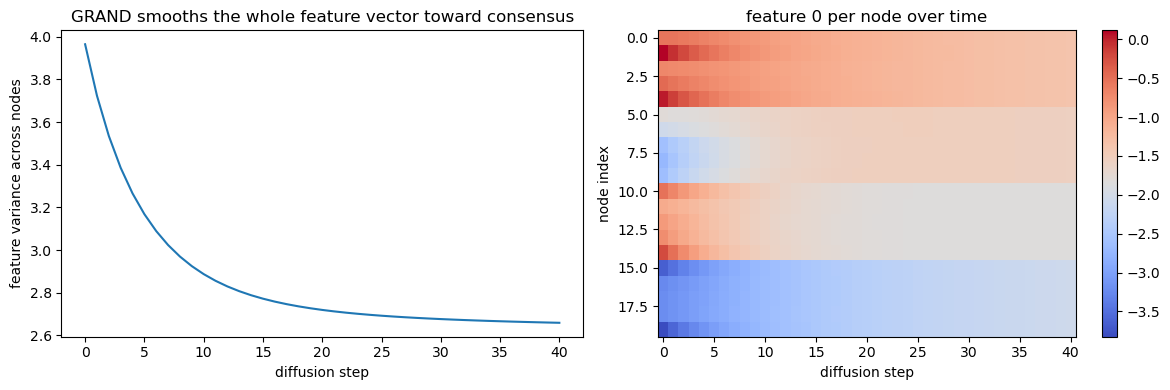

feature variance: 3.9648 -> 2.6589 after 40 diffusion steps


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(variances)
axes[0].set(xlabel="diffusion step", ylabel="feature variance across nodes",
            title="GRAND smooths the whole feature vector toward consensus")
im = axes[1].imshow(feature0_over_time.T, aspect="auto", cmap="coolwarm")
axes[1].set(xlabel="diffusion step", ylabel="node index", title="feature 0 per node over time")
fig.colorbar(im, ax=axes[1])
fig.tight_layout()
plt.show()

print(f"feature variance: {variances[0]:.4f} -> {variances[-1]:.4f} after {STEPS} diffusion steps")


## Key takeaway

GRAND diffuses **every** latent coordinate toward a local consensus — it
has no notion of "phase" and will happily average an angular coordinate the
same way it averages any other feature, which is exactly why the full
model keeps a *separate* Kuramoto term (notebook 04) for the angular
coordinate and gates between the two (notebook 06) rather than diffusing
everything indiscriminately.